<a href="https://colab.research.google.com/github/kjahan/stable_diffusion_demo/blob/master/notebooks/Stable_Diffusion_with_ChatGPT_Prompter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Diffusion v1.5 vs Midjourney v4 Diffusion mixed with ChatGPT prompter


https://huggingface.co/prompthero/midjourney-v4-diffusion

https://github.com/amrrs/midjourney4-stable-diffusion/blob/main/MidJourney_Style_Images_from_Fine_tuned_Stable_Diffusion.ipynb

https://www.youtube.com/watch?v=nYi1dE3qK6U

In [1]:
!pip install transformers diffusers accelerate -q

     |████████████████████████████████| 5.8 MB 40.5 MB/s 
     |████████████████████████████████| 524 kB 60.1 MB/s 
     |████████████████████████████████| 191 kB 73.3 MB/s 
     |████████████████████████████████| 182 kB 76.0 MB/s 
     |████████████████████████████████| 7.6 MB 9.7 MB/s 


In [2]:
from diffusers import StableDiffusionPipeline
import torch

import time

In [5]:
model_path = 'prompthero/midjourney-v4-diffusion'
pipe = StableDiffusionPipeline.from_pretrained(model_path , torch_dtype=torch.float16)

Downloading:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Downloading:   0%|          | 0.00/342 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/4.84k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

Downloading:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/547 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/335M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [6]:
!nvidia-smi

Sun Jan  1 21:50:28 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P8     9W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [7]:
if torch.cuda.is_available():
  pipe = pipe.to("cuda")

device = "GPU 🔥" if torch.cuda.is_available() else "CPU 🥶"

In [8]:
device

'GPU 🔥'

## Image Generators

In [9]:
def generate_image(base_prompt):
  prompt = "mdjrny-v4 style " + base_prompt

  print(prompt)
  result = pipe(
        prompt,  
        width = 512,
        height = 512)
  image = result.images[0]  
      
  image.save("sd_img_{}.png".format(int(time.time())))

  return image

In [10]:
def generate_image_with_neg(pos_prompt, neg_prompt=""):
  prompt = "mdjrny-v4 style " + pos_prompt

  print(prompt)
  if neg_prompt:
    result = pipe(
          prompt=pos_prompt,
          negative_prompt=neg_prompt,
          width = 512,
          height = 512)
  else:
    result = pipe(
          prompt=pos_prompt,
          width = 512,
          height = 512)
  image = result.images[0]  
      
  image.save("sd_img_{}.png".format(int(time.time())))

  return image

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# ChatGPT as prompt generator

https://www.youtube.com/watch?v=VjbCnflSzEk
https://pastebin.com/5ASBHJb5

Input:
this is called a “prompt for stable diffusion" of a portrait of Christina Hendricks with cosmic energy in the background in the art style of artists called "artgerm", "greg rutkowski" and "alphonse mucha":
"Ultra realistic photo portrait of Christina Hendricks cosmic energy, colorful, painting burst, beautiful face, symmetrical face, tone mapped, intricate, elegant, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, beautiful face, intricate, highly detailed, smooth, sharp focus, art by artgerm and greg rutkowski and alphonse mucha"
 
The most important keywords are at the beginning and then every additional keywords are separated by a comma. If you add an art style by an artist or multiple artists, this information should always be at the end.
 
By using a similar syntax, please write me a new "prompt for stable diffusion" of a “portrait of a cute Hogwarts student studying” in the art style of "van gogh" and "da vinci" but add more details

Output:
"Portrait of cute Hogwarts student studying, peaceful expression, quill in hand, ancient tomes, magic glowing in the background, van gogh and da vinci inspired art style, swirling brushstrokes, warm colors, intricate details, mystical atmosphere, charming and whimsical"

### ChatGPT idea
https://twitter.com/dreamwieber/status/1603951837836894208/photo/1

In [15]:
prompt = 'Generate an image that represents the concept of a fourth dimension. This could be depicted through the use of visual metaphors, such as a three-dimensional object being "stretched" or "warped" in a way that suggests the existence of an additional dimension.'

img = generate_image(prompt)

mdjrny-v4 style Generate an image that represents the concept of a fourth dimension. This could be depicted through the use of visual metaphors, such as a three-dimensional object being "stretched" or "warped" in a way that suggests the existence of an additional dimension.


  0%|          | 0/50 [00:00<?, ?it/s]

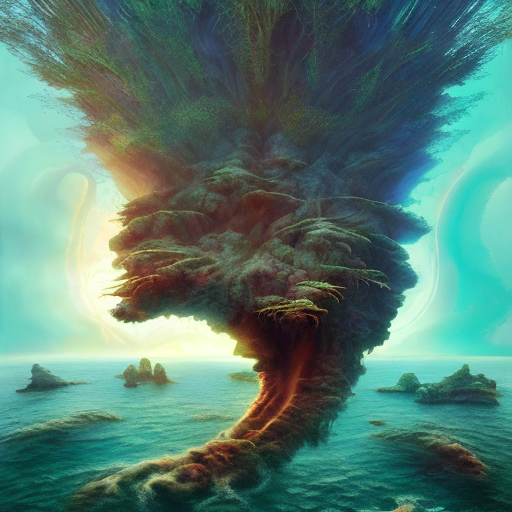

In [14]:
img

## Infinity

what's one of the hardest concepts for a human mind to visualize? Write a
prompt for an Al image generator to try and create that image.

One of the hardest concepts for a human mind to visualize is the concept of infinity. It is difficult for us to wrap our heads around the idea of something that has no end or limit.

Prompt for an AI image generator: "Create an image that visually represents the concept of infinity. This could be a spiral that never ends, a repeating pattern that goes on indefinitely, or any other creative interpretation of the idea of something that has no end or limit."

In [20]:
prompt = "Create an image that visually represents the concept of infinity. This could be a spiral that never ends, a repeating pattern that goes on indefinitely, or any other creative interpretation of the idea of something that has no end or limit."
img2 = generate_image(prompt)

mdjrny-v4 style Create an image that visually represents the concept of infinity. This could be a spiral that never ends, a repeating pattern that goes on indefinitely, or any other creative interpretation of the idea of something that has no end or limit.


  0%|          | 0/50 [00:00<?, ?it/s]

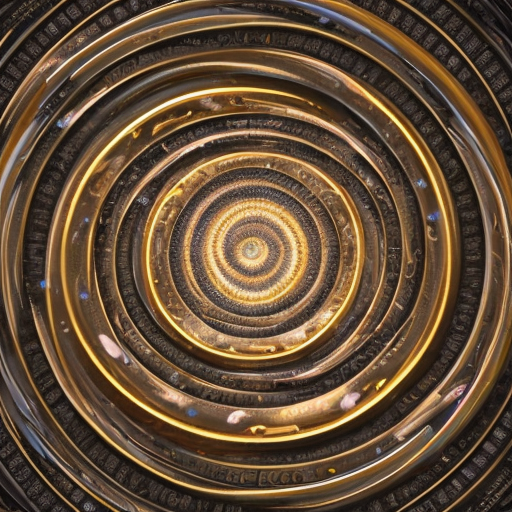

In [21]:
img2

## Ideas

https://www.reddit.com/r/StableDiffusion/comments/za72ny/you_can_use_chatgpt_to_generate_full_prompts_to/


Write a prompt describing: an astronaut riding a dinosaur on the moon.


Here is a prompt for an AI image generator to create an image of an astronaut riding a dinosaur on the moon:

"Create an image of an astronaut riding a dinosaur on the surface of the moon. The astronaut should be wearing a space suit and riding on the back of a recognizable dinosaur species, such as a velociraptor or triceratops. The background should depict the moon's surface, with craters and other lunar features visible in the distance. The image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a prehistoric beast."





In [24]:
prompt = "Create an image of an astronaut riding a dinosaur on the surface of the moon. The astronaut should be wearing a space suit and riding on the back of a recognizable dinosaur species, such as a velociraptor or triceratops. The background should depict the moon's surface, with craters and other lunar features visible in the distance. The image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a prehistoric beast."

img3 = generate_image(prompt)

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['the distance. the image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a prehistoric beast.']


mdjrny-v4 style Create an image of an astronaut riding a dinosaur on the surface of the moon. The astronaut should be wearing a space suit and riding on the back of a recognizable dinosaur species, such as a velociraptor or triceratops. The background should depict the moon's surface, with craters and other lunar features visible in the distance. The image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a prehistoric beast.


  0%|          | 0/50 [00:00<?, ?it/s]

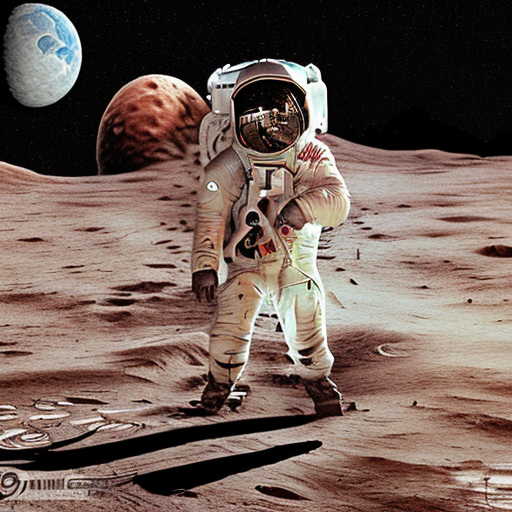

In [25]:
img3

In [26]:
prompt = "Create an image of an astronaut riding a camel on the surface of the moon. The astronaut should be wearing a space suit and riding on the back of a camel with a distinctive appearance, such as a dromedary camel with a single hump or a Bactrian camel with two humps. The background should depict the moon's surface, with craters and other lunar features visible in the distance. The image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a camel."

img4 = generate_image(prompt)

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['s surface, with craters and other lunar features visible in the distance. the image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a camel.']


mdjrny-v4 style Create an image of an astronaut riding a camel on the surface of the moon. The astronaut should be wearing a space suit and riding on the back of a camel with a distinctive appearance, such as a dromedary camel with a single hump or a Bactrian camel with two humps. The background should depict the moon's surface, with craters and other lunar features visible in the distance. The image should be colorful and realistic, giving the viewer a sense of what it might be like to explore the moon on the back of a camel.


  0%|          | 0/50 [00:00<?, ?it/s]

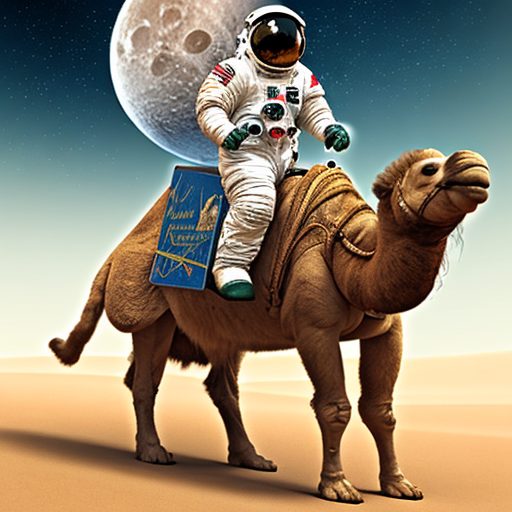

In [27]:
img4